# Capstone Function 2
Imagine a black box, or a mystery ML model, that takes two numbers as input, and returns a log-likelihood score. Goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.
To tackle this, you use Bayesian Optimisation, which selects the next inputs based on what it has learnt so far.  Balances exploration iwth exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

 Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

### Step 1: Import Required Libraries

Import necessary libraries for Bayesian Optimization, data handling, and visualization.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
PyTorch version: 2.10.0


### Step 2: Load and Display Initial Data

Load the initial input and output data for the noisy log-likelihood optimization problem.

In [2]:
# Load initial data
X_init = np.load('../../data/f2/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f2/updated_outputs - Week 4.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape}")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

Initial Data Summary:
Input shape: (10, 2)
Output shape: (10,)

Input range: [0.0287, 0.9266]
Output range: [-0.065624, 0.611205]
Output mean: 0.230674
Output std: 0.225365

Best observed value: 0.611205
Best input location: [0.70263656 0.9265642 ]

First 5 samples:
  X[0] = [0.66579958 0.12396913], y[0] = 0.538996
  X[1] = [0.87779099 0.7786275 ], y[1] = 0.420586
  X[2] = [0.14269907 0.34900513], y[2] = -0.065624
  X[3] = [0.84527543 0.71112027], y[3] = 0.293993
  X[4] = [0.45464714 0.29045518], y[4] = 0.214965


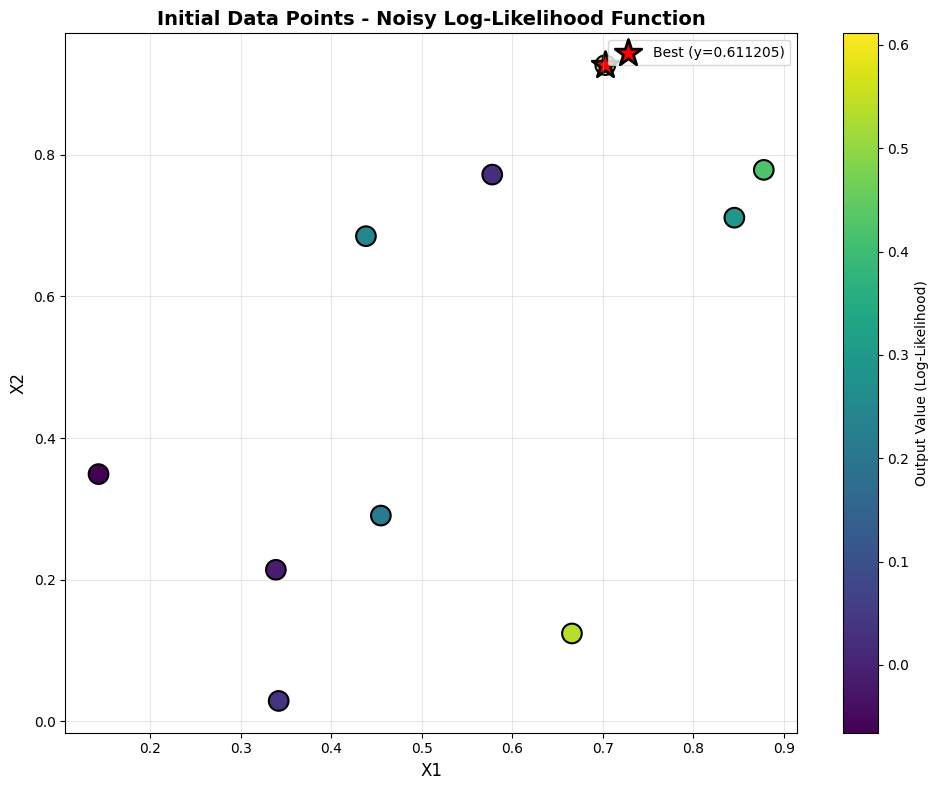

In [3]:
# Visualize initial data points in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=200, cmap='viridis', edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Output Value (Log-Likelihood)')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Initial Data Points - Noisy Log-Likelihood Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the best point
best_idx = y_init.argmax()
plt.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label=f'Best (y={y_init[best_idx]:.6f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Gaussian Process Kernel**: Matern 5/2 (BoTorch default)
   - **Why**: Robust to noise, which is critical for this noisy log-likelihood function
   - Twice differentiable, providing smooth predictions

2. **Acquisition Function**: Expected Improvement (EI)
   - **Why**: Handles noisy observations well by averaging over uncertainty
   - Good at avoiding local optima through exploration-exploitation balance
   - Well-suited for problems with multiple local peaks

3. **Number of Restarts for Acquisition Optimization**: 10
   - **Why**: Important for noisy functions to avoid getting stuck in local optima
   - Multiple restarts ensure robust acquisition function optimization

4. **Number of Raw Samples**: 512
   - **Why**: Thorough initial sampling to find good starting points
   - Helps navigate complex landscape with potential local maxima

5. **Input Bounds**: [0, 0.999999] for all dimensions
   - **Why**: Required by submission format - all inputs must be in range [0, 0.999999]

6. **Standardize Outputs**: Yes (automatic in SingleTaskGP)
   - **Why**: Critical for numerical stability with varying output scales
   - GP noise model learns appropriate noise level from data

In [ ]:
# Define hyperparameters
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]  # Number of dimensions
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)

NUM_RESTARTS = 10  # Number of restarts for acquisition function optimization
RAW_SAMPLES = 512  # Number of initial random samples for acquisition optimization

print("Hyperparameters:")
print(f"  Input bounds: [0, 0.999999] for all {N_DIM} dimensions")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2 (default)")
print(f"  Number of restarts: {NUM_RESTARTS}")
print(f"  Raw samples: {RAW_SAMPLES}")
print(f"  Output standardization: Yes (SingleTaskGP handles this)")

Hyperparameters:
  Input bounds: 
[[ 0.04269907 -0.07130228]
 [ 0.97779099  1.0265642 ]]
  Acquisition function: Expected Improvement (EI)
  GP Kernel: Matern 5/2 (default)
  Number of restarts: 10
  Raw samples: 512
  Output standardization: Yes (SingleTaskGP handles this)


### Step 4: Build Gaussian Process Surrogate Model

Create and train a Gaussian Process model on the initial data. The GP learns patterns in the noisy observations.

In [5]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create Gaussian Process model
gp_model = SingleTaskGP(X_train, y_train)

# Define the marginal log likelihood
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

# Fit the GP model to the data
print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")
print(f"\nNote: Noise variance estimates observational noise in the log-likelihood function")

Training data shape: X=torch.Size([10, 2]), y=torch.Size([10, 1])

Training Gaussian Process model...
✓ Model training complete!

Learned GP Hyperparameters:
  Noise variance: 0.007591
  Length scales: [[0.0595624  1.80365489]]

Note: Noise variance estimates observational noise in the log-likelihood function


### Step 5: Optimize Acquisition Function to Propose Next Sample

Use Expected Improvement to find the next most promising point to evaluate.

In [6]:
# Create Expected Improvement acquisition function
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize the acquisition function
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Extract the proposed next point
next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement value: {acq_value.item():.6f}")

Best observed value: 0.611205

Optimizing acquisition function...
✓ Optimization complete!

Proposed next sample point:
  X_next = [ 0.70730002 -0.07130228]
  Expected Improvement value: 0.028510


### Step 6: Visualize Surrogate Function

Visualize the GP mean prediction and uncertainty across the 2D search space.

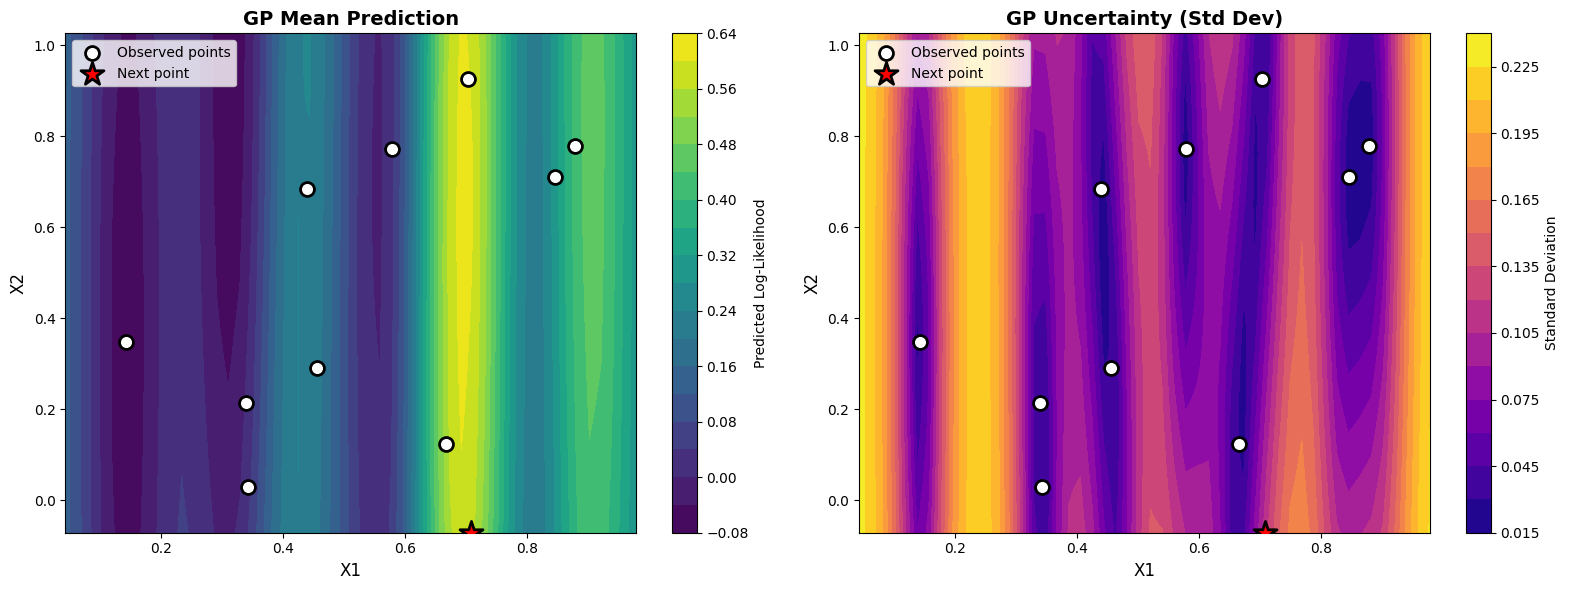

GP captures trends despite noise. Uncertainty highest in unexplored regions.


In [7]:
# Create a grid for visualization
n_grid = 50
x1_range = np.linspace(BOUNDS[0, 0].item(), BOUNDS[1, 0].item(), n_grid)
x2_range = np.linspace(BOUNDS[0, 1].item(), BOUNDS[1, 1].item(), n_grid)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_grid_torch = torch.tensor(X_grid, dtype=torch.float64)

# Get GP predictions
gp_model.eval()
with torch.no_grad():
    posterior = gp_model.posterior(X_grid_torch)
    mean = posterior.mean.numpy().reshape(n_grid, n_grid)
    std = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GP Mean Prediction
im1 = axes[0].contourf(X1_grid, X2_grid, mean, levels=20, cmap='viridis')
axes[0].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[0].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('GP Mean Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Predicted Log-Likelihood')

# Plot 2: GP Uncertainty
im2 = axes[1].contourf(X1_grid, X2_grid, std, levels=20, cmap='plasma')
axes[1].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[1].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('GP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Standard Deviation')

plt.tight_layout()
plt.show()

print(f"GP captures trends despite noise. Uncertainty highest in unexplored regions.")

### Step 7: Visualize Acquisition Function

Show the Expected Improvement values across the search space.

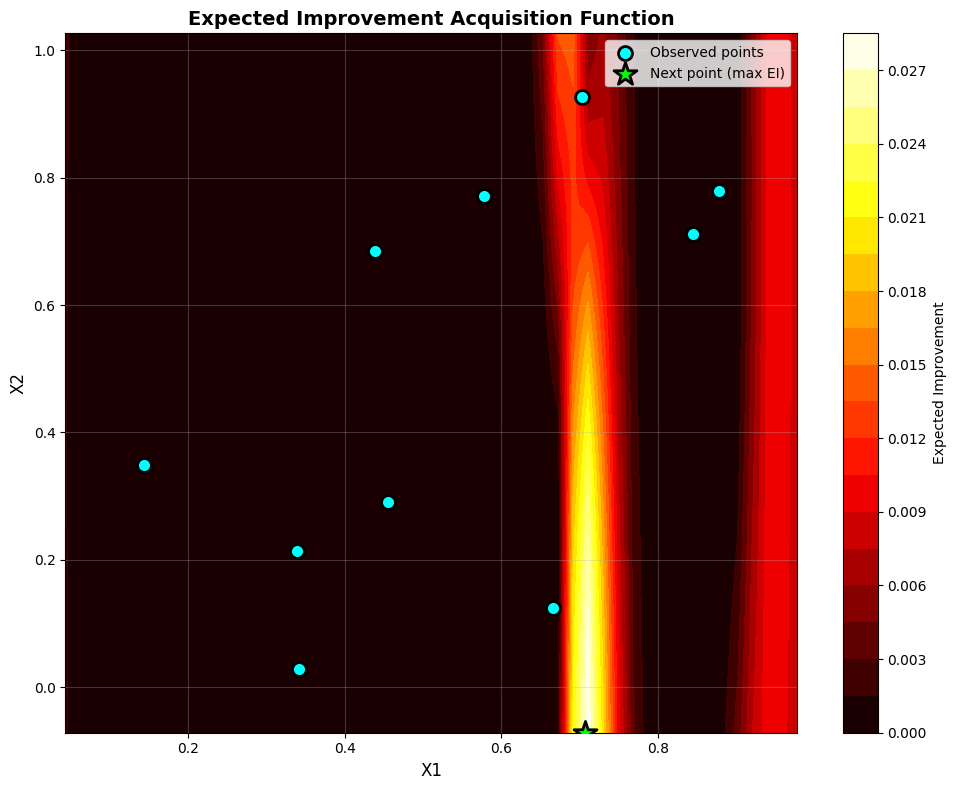

EI balances exploring uncertain regions and exploiting promising areas.


In [8]:
# Compute Expected Improvement values across the grid
with torch.no_grad():
    ei_values = EI(X_grid_torch.unsqueeze(1)).numpy().reshape(n_grid, n_grid)

# Visualize Expected Improvement
plt.figure(figsize=(10, 8))
im = plt.contourf(X1_grid, X2_grid, ei_values, levels=20, cmap='hot')
plt.scatter(X_init[:, 0], X_init[:, 1], c='cyan', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
plt.scatter(next_point[0], next_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point (max EI)', zorder=6)
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Expected Improvement Acquisition Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EI balances exploring uncertain regions and exploiting promising areas.")

### Step 8: Track Optimization Progress

Monitor the best observed value over iterations.

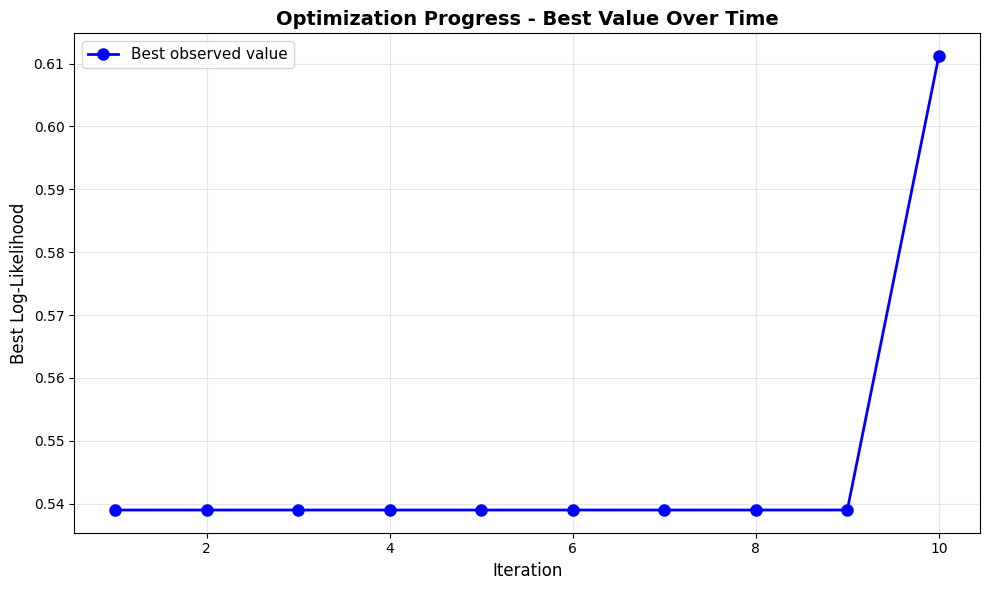

Starting best value: 0.611205
After 10 initial samples, awaiting next evaluation...

Next submission: [ 0.70730002 -0.07130228]


In [9]:
# Track the best value found so far at each iteration
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Log-Likelihood', fontsize=12)
plt.title('Optimization Progress - Best Value Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples, awaiting next evaluation...")
print(f"\nNext submission: {next_point}")

### Step 9: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
if acq_value.item() > 0.1:
    print("  → High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  → Moderate EI: Some exploration potential remains")
else:
    print("  → Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**Initial Submission Complete**

- Loaded 10 initial data points for noisy 2D log-likelihood optimization
- Built Gaussian Process surrogate model with Matern 5/2 kernel
- Model handles noisy observations through learned noise variance
- Used Expected Improvement acquisition function
- Proposed next sample point for evaluation
- Visualized surrogate function, uncertainty, and acquisition landscape

**Key Considerations for Noisy Function:**
- GP noise model captures observation uncertainty
- Multiple local optima require careful exploration
- Expected Improvement naturally handles noise through probabilistic predictions

**Next Steps:**
1. Submit the proposed point for evaluation
2. Receive the observation result
3. Add to dataset and retrain model
4. Propose next point (repeat process)